# Lab Work - 2.3

## Q.1.House Price Prediction Errors

Objective: Evaluate prediction errors using MSE, MAE, and RMSE.

Task Steps:
1. Create two arrays:
- Actual house prices (10 values)
- Predicted house prices (10 values)
2. Calculate:
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
3. Compare which metric shows higher penalty for large errors.

In [1]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

actual_price = np.array([
    180000,
    250000,
    320000,
    450000,
    600000,
    150000,
    290000,
    380000,
    520000,
    200000
])

predicted_price = np.array([
    185000,
    245000,
    330000,
    440000,
    590000,
    160000,
    300000,
    375000,
    510000,
    210000
])

y_true = actual_price
y_pred = predicted_price

print("Actual Prices:\n", actual_price)
print("\nPredicted Prices:\n", predicted_price)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
metrics_values = {"MSE":mse, "MAE":mae, "RMSE":rmse}
for i, v in metrics_values.items():
    print(f"{i}: {v}")

Actual Prices:
 [180000 250000 320000 450000 600000 150000 290000 380000 520000 200000]

Predicted Prices:
 [185000 245000 330000 440000 590000 160000 300000 375000 510000 210000]
MSE: 77500000.0
MAE: 8500.0
RMSE: 8803.408430829504


## Q.2. Salary Prediction Model

Objective: Understand impact of prediction errors visually.

Task Steps:
1. Generate a dataset of experience (X) vs salary (y).
2. Fit a simple linear regression model.
3. Predict salaries using the model.
4. Compute MSE, MAE, RMSE.
5. Plot actual vs predicted values.

[109802.13482266  56058.8744277  100030.63293267  41401.62159272
 100030.63293267 124459.38765764 100030.63293267  65830.3763177
  65830.3763177   60944.6253727   85373.38009768  60944.6253727
 100030.63293267 114687.88576765  60944.6253727   65830.3763177
  60944.6253727   70716.12726269  36515.87064772  70716.12726269]
[111774  48304  95791  37526  99474 125230  91678  62777  67685  69115
  93141  59789  90202 107693  52811  69948  54389  62327  42868  76312]
MSE: 36126936.236473724
MAE: 5274.550736036982
RMSE: 6010.568711567461


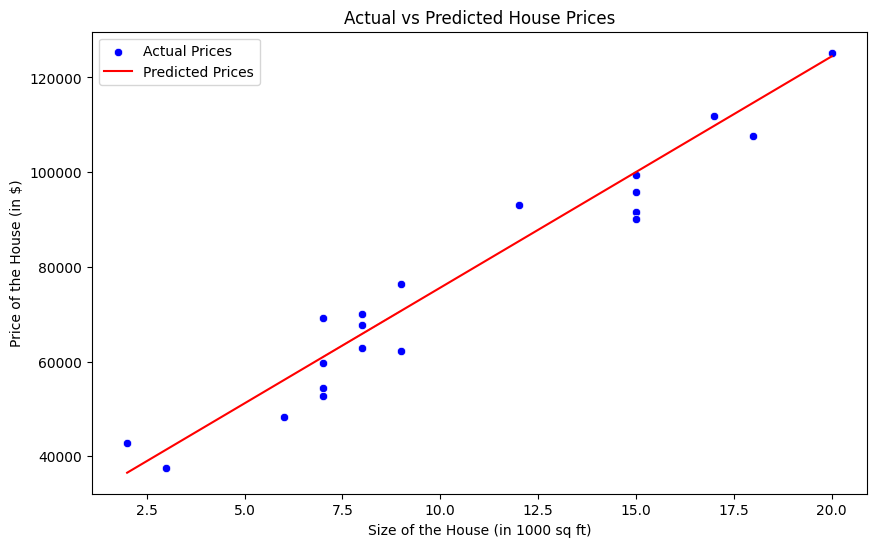

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

X = np.random.randint(1, 21, 100)

y = 25000 + (X * 5000) + np.random.randint(-10000, 10000, 100)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

lr = LinearRegression()

X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)
X_test = pd.DataFrame(X_test)
y_test = pd.DataFrame(y_test)

lr.fit(X_train, y_train)

y_pred = np.array(lr.predict(X_test)).flatten()
print(y_pred)
print(np.array(y_test).flatten())

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
metrics_values = {"MSE":mse, "MAE":mae, "RMSE":rmse}
for i, v in metrics_values.items():
    print(f"{i}: {v}")

# Ploting
plt.figure(figsize=(10, 6))
sns.scatterplot(x=np.array(X_test).flatten(), y=np.array(y_test).flatten(), color='blue', label='Actual Prices')
sns.lineplot(x=np.array(X_test).flatten(), y=y_pred, color='red', label='Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Size of the House (in 1000 sq ft)')
plt.ylabel('Price of the House (in $)')
plt.legend()
plt.show()

## Q.3. Error Comparison on Two Models

Objective: Compare performance of two different prediction models.

Task Steps:
1. Create actual values (15 data points).
2. Create two predicted arrays (Model A and Model B).
3. Compute MSE, MAE, RMSE for both models.
4. Identify which model performs better based on errors.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
def create_model_plus_metrics(x, y, random_state):
    model = LinearRegression()
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=random_state)
    X_train_multi = pd.DataFrame(X_train)
    y_train_multi = pd.DataFrame(y_train)
    X_test_multi = pd.DataFrame(X_test)
    y_test_multi = pd.DataFrame(y_test)
    model.fit(X_train_multi, y_train_multi)
    y_pred = np.array(model.predict(X_test_multi)).flatten()
    mse = mean_squared_error(y_test_multi, y_pred)
    mae = mean_absolute_error(y_test_multi, y_pred)
    rmse = root_mean_squared_error(y_test_multi, y_pred)
    return_values = {"Model": model, "MSE": mse, "MAE": mae, "RMSE": rmse, "X_train": X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test, "X_train_multi": X_train_multi, "y_train_multi": y_train_multi, "X_test_multi": X_test_multi, "y_test_multi": y_test_multi, "y_pred": y_pred, "Random_State": random_state}
    return return_values

model1_results = create_model_plus_metrics(X, y, 0)
model2_results = create_model_plus_metrics(X, y, 42)

for i in ["MSE", "MAE", "RMSE"]:
    print(f"Model 1 {i}: {model1_results[i]}")
    print(f"Model 2 {i}: {model2_results[i]}")

def compare_choose_model(*models):
    best_model = None
    best_mse = float('inf')
    for model in models:
        if model["MSE"] < best_mse:
            best_model = model
    return best_model

best_model = compare_choose_model(model1_results, model2_results)
if best_model["MSE"] == model1_results["MSE"]:
    best_model["Name"] = "Model 1"
else:
    best_model["Name"] = "Model 2"
print("Best Model:", best_model["Name"])
print("Best Model MSE:", best_model["MSE"])
print("Best Model Random State:", best_model["Random_State"])

Model 1 MSE: 36577835.112003714
Model 2 MSE: 36126936.236473724
Model 1 MAE: 4933.4546830925665
Model 2 MAE: 5274.550736036982
Model 1 RMSE: 6047.961235987192
Model 2 RMSE: 6010.568711567461
Best Model: Model 2
Best Model MSE: 36126936.236473724
Best Model Random State: 42


## Q.4. R2 Score Interpretation

Objective: Understand how well the model explains variance.

Task Steps:
1. Generate a dataset (X vs y) with linear relation.
2. Fit a simple linear regression model.
3. Calculate R2 score.
4. Interpret whether model is good or not.

LINEAR REGRESSION MODEL
Slope (m): 1.9578
Intercept (b): 5.9566

Regression Equation:
y = 1.96x + 5.96

MODEL EVALUATION
R² Score  : 0.9934
MSE       : 1.5432
RMSE      : 1.2423
MAE       : 1.0745

INTERPRETATION
Excellent model fit ✅


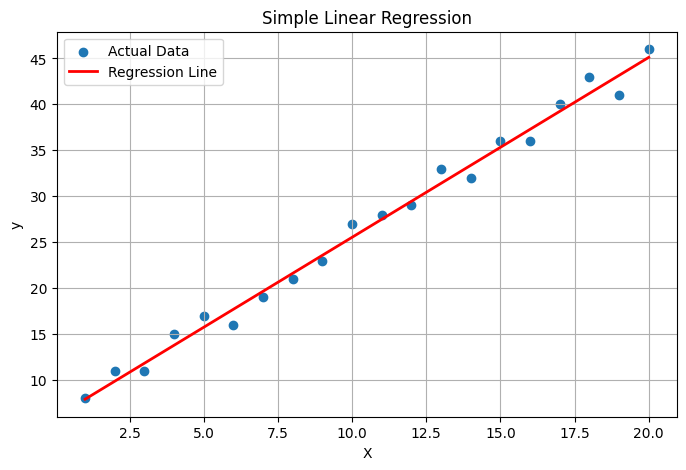

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = np.arange(1, 21).reshape(-1, 1)

noise = np.random.randint(-2, 3, size=20)
y = 2 * X.flatten() + 5 + noise

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

slope = model.coef_[0]
intercept = model.intercept_

print("=" * 50)
print("LINEAR REGRESSION MODEL")
print("=" * 50)

print(f"Slope (m): {slope:.4f}")
print(f"Intercept (b): {intercept:.4f}")

print(f"\nRegression Equation:")
print(f"y = {slope:.2f}x + {intercept:.2f}")

r2 = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)

print("\n" + "=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print(f"R² Score  : {r2:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"MAE       : {mae:.4f}")

print("\n" + "=" * 50)
print("INTERPRETATION")
print("=" * 50)

if r2 >= 0.9:
    print("Excellent model fit ✅")
elif r2 >= 0.7:
    print("Good model fit 👍")
elif r2 >= 0.5:
    print("Moderate model fit ⚠️")
else:
    print("Weak model fit ❌")

plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual Data")

plt.plot(X, model.predict(X), linewidth=2, label="Regression Line", color='red')

plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

## Q.5. Adjusted R2 Calculation

Objective: Understand the need for adjusted R2.

Task Steps:
1. Use dataset with:
    - One independent variable (X)
    - One dependent variable (y)
2. Calculate R2 score.
3. Manually compute Adjusted R2 using formula.
4. Compare both values.

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([2,4,5,4,5,7,8,9,10,12])

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)

n = len(y)
p = X.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("R² Score:", r2)
print("Adjusted R²:", adjusted_r2)

R² Score: 0.9446044151926505
Adjusted R²: 0.9376799670917317


## Q.6. Effect of Adding Irrelevant Feature

Objective: Observe difference between R2 and Adjusted R2.

Task Steps:
1. Create dataset with:
    - One meaningful feature
    - One random/irrelevant feature
2. Fit regression model with both features.
3. Calculate R2 and Adjusted R2.
4. Observe how metrics change after adding irrelevant feature.

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)

n = 100

X1 = np.random.rand(n)

y = 5 * X1 + np.random.normal(0, 0.2, n)

X2 = np.random.rand(n)

X_single = pd.DataFrame({'X1': X1})

model1 = LinearRegression()
model1.fit(X_single, y)

pred1 = model1.predict(X_single)

r2_1 = r2_score(y, pred1)

p1 = X_single.shape[1]

adj_r2_1 = 1 - ((1 - r2_1) * (n - 1) / (n - p1 - 1))

X_both = pd.DataFrame({
    'X1': X1,
    'X2': X2
})

model2 = LinearRegression()
model2.fit(X_both, y)

pred2 = model2.predict(X_both)

r2_2 = r2_score(y, pred2)

p2 = X_both.shape[1]

adj_r2_2 = 1 - ((1 - r2_2) * (n - 1) / (n - p2 - 1))

print("Model with only meaningful feature")
print("R²:", round(r2_1, 4))
print("Adjusted R²:", round(adj_r2_1, 4))

print("\nModel with meaningful + irrelevant feature")
print("R²:", round(r2_2, 4))
print("Adjusted R²:", round(adj_r2_2, 4))

print("\nObservation:")
if r2_2 > r2_1:
    print("R² increased after adding irrelevant feature")

if adj_r2_2 < adj_r2_1:
    print("Adjusted R² decreased because irrelevant feature adds penalty")

print("\nConclusion:")
print("R² tends to increase with extra variables")
print("Adjusted R² penalizes unnecessary features")

Model with only meaningful feature
R²: 0.9849
Adjusted R²: 0.9848

Model with meaningful + irrelevant feature
R²: 0.9851
Adjusted R²: 0.9847

Observation:
R² increased after adding irrelevant feature
Adjusted R² decreased because irrelevant feature adds penalty

Conclusion:
R² tends to increase with extra variables
Adjusted R² penalizes unnecessary features
